<a href="https://colab.research.google.com/github/McKendreevv/Mis433/blob/main/MVV_text_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Text Analytics

Text analytics turns unstructured language into data that can be counted, compared, visualized, and modeled. Unlike many tabular datasets, text is high-dimensional: a single column of comments, reviews, emails, or news articles can contain thousands of unique words, phrases, spellings, and meanings.

The main challenge is representation. Before we can summarize or model text, we need to decide how to convert language into numeric features while preserving enough meaning for the task. In this notebook, we will practice common steps in that workflow: cleaning and exploring text, converting text to document-term matrices, finding frequent words, measuring word importance with TF-IDF, clustering similar documents, creating word clouds, and estimating sentiment.

# Load and explore data from csv

Source: https://www.kaggle.com/datasets/cloudy17/bob-dylan-songs/

**Context**
This dataset contains songs from years between 1961 to 2020 written by Bob Dylan.

**Content**
There are 4 columns:
* release_year - year when song was released first time,
* album - name of the album where track occurs,
* title - title of the song,
* lyrics - lyrics of the track

In [1]:
import pandas as pd

# load dataset from csv
df = pd.read_csv('https://raw.githubusercontent.com/jiexunli-wwu/mis433/refs/heads/main/data/bob-dylan.csv')
df.head(3) # show the first three rows

,release_year,album,title,lyrics
0,1961,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Hard Times In New York Town,"Come you ladies and you gentlemen, a-listen to..."
1,1961,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Man on the street,"’ll sing you a song, ain’t very long\n\n’Bout ..."
2,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Talkin’ Bear Mountain Picnic Massacre Blues,I saw it advertised one day\n\nBear Mountain p...


In [2]:
# shape of the df: rows and columns
df.shape

(345, 4)

In [3]:
# the data types of each column
df.dtypes

,0
release_year,int64
album,object
title,object
lyrics,object


In [4]:
# Get a summary of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 345 entries, 0 to 344
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   release_year  345 non-null    int64 
 1   album         345 non-null    object
 2   title         345 non-null    object
 3   lyrics        345 non-null    object
dtypes: int64(1), object(3)
memory usage: 10.9+ KB


In [5]:
# Count the values of a column
df.release_year.value_counts()

,count
release_year,
1975,30
1965,22
1963,22
1964,21
1970,19
1966,15
1967,13
1981,13
1983,13


In [6]:
df.album.value_counts()

,count
album,
"The Bootleg Series, Vol 1-3: Rare & Unreleased 1961-1991",37
The Basement Tapes,16
The Freewheelin',13
Blonde on Blonde,13
New Morning,12
John Wesley Harding,12
“Love and Theft”,12
Bringing It All Back Home,11
Under the Red Sky,10


In [7]:
# Add a new column
df['decade'] = (df['release_year'] // 10) * 10
df.head()

,release_year,album,title,lyrics,decade
0,1961,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Hard Times In New York Town,"Come you ladies and you gentlemen, a-listen to...",1960
1,1961,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Man on the street,"’ll sing you a song, ain’t very long\n\n’Bout ...",1960
2,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Talkin’ Bear Mountain Picnic Massacre Blues,I saw it advertised one day\n\nBear Mountain p...,1960
3,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Let Me Die in My Footsteps,I will not go down under the ground\n\n’Cause ...,1960
4,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...","Rambling, Gambling Willie",Come around you rovin’ gamblers and a story I ...,1960


In [8]:
# String Operations
# Count the number of words in each song.

df['word_count'] = df['lyrics'].apply(lambda x: len(x.split()))
df.head()

,release_year,album,title,lyrics,decade,word_count
0,1961,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Hard Times In New York Town,"Come you ladies and you gentlemen, a-listen to...",1960,353
1,1961,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Man on the street,"’ll sing you a song, ain’t very long\n\n’Bout ...",1960,158
2,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Talkin’ Bear Mountain Picnic Massacre Blues,I saw it advertised one day\n\nBear Mountain p...,1960,391
3,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Let Me Die in My Footsteps,I will not go down under the ground\n\n’Cause ...,1960,365
4,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...","Rambling, Gambling Willie",Come around you rovin’ gamblers and a story I ...,1960,477


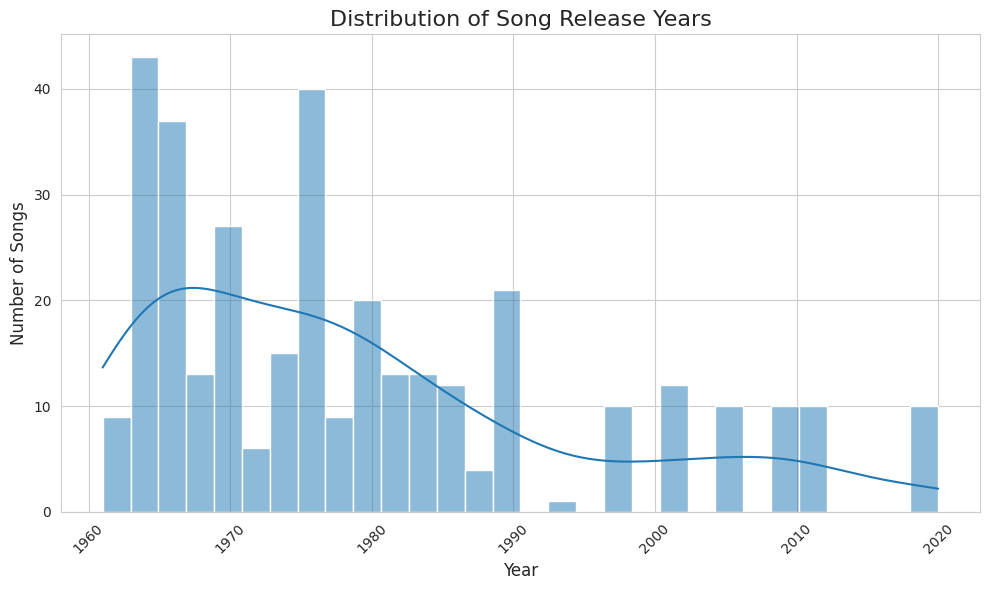

In [9]:
# Visualization

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid') # Set a prettier style

plt.figure(figsize=(10, 6)) # Adjust figure size for better readability
sns.histplot(df['release_year'], bins=30, kde=True) # Use seaborn's histplot with kde for density estimate
plt.title('Distribution of Song Release Years', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Songs', fontsize=12)
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

## scikit-learn

Scikit-learn is one of the most popular Python packages for predictive data analysis. It includes tools for preprocessing text, building feature matrices, clustering documents, and training machine learning models.

https://scikit-learn.org/

If scikit-learn is not installed in your environment, uncomment and run the next cell.

In [10]:
 #!pip install scikit-learn

### Vectorization: Converting Text to Numeric Form

Text data must be converted into a numeric form before it can be used with machine learning algorithms. A common technique is `CountVectorizer`, which converts a collection of documents into a document-term matrix. Each row is a document, each column is a token, and each value is the number of times that token appears in that document.

In [11]:
from sklearn.feature_extraction.text import CountVectorizer

# Example using the 'lyrics' column of the Bob Dylan dataset
corpus = df['lyrics'].dropna().tolist()  # Assuming df is your DataFrame and dropping any missing values
vectorizer = CountVectorizer(stop_words='english')  # Remove common 'stop words'
X = vectorizer.fit_transform(corpus)

print(X.shape)  # Shows the shape of the matrix


(345, 7326)


In [12]:
# Accessing the Vocabulary
vocabulary = vectorizer.vocabulary_

# Print the vocabulary dictionary (word: column index)
print(vocabulary)

{'come': 1220, 'ladies': 3508, 'gentlemen': 2630, 'listen': 3691, 'song': 5938, 'sing': 5777, 'right': 5267, 'think': 6491, 'wrong': 7278, 'just': 3423, 'little': 3698, 'glimpse': 2681, 'story': 6172, 'll': 3707, 'tell': 6439, 'bout': 662, 'east': 1989, 'coast': 1182, 'city': 1111, 'know': 3492, 'hard': 2896, 'times': 6558, 'livin': 3704, 'new': 4247, 'york': 7313, 'town': 6627, 'old': 4352, 'friendly': 2531, 'washington': 7031, 'heights': 2981, 'harlem': 2902, 'mighty': 4008, 'people': 4601, 'millin': 4015, 'kick': 3443, 'knock': 3484, 'long': 3731, 'ways': 7056, 'golden': 2706, 'gate': 2605, 'rockefeller': 5321, 'plaza': 4741, 'empire': 2045, 'state': 6108, 'mister': 4055, 'sets': 5607, 'high': 3011, 'bird': 501, 'says': 5488, 'word': 7229, 'country': 1373, 'mornin': 4113, 'tryin': 6734, 'job': 3371, 'work': 7232, 'stand': 6079, 'place': 4706, 'till': 6552, 'feet': 2270, 'begin': 438, 'hurt': 3161, 'got': 2727, 'lot': 3760, 'money': 4084, 'make': 3847, 'merry': 3984, 'nickel': 4256, 

In [13]:
# Size of the vocabulary
len(vocabulary)

7326

In [14]:
# View the first document's feature vector
document_index = 0
feature_vector_sparse = X.getrow(document_index)

# To convert to a dense array
feature_vector_dense = feature_vector_sparse.toarray()

print(feature_vector_dense)

[[0 0 0 ... 0 0 0]]


In [15]:
# To View as a Readable Format

# Get feature names
feature_words = vectorizer.get_feature_names_out()

# Convert the sparse matrix row to a dense array
feature_vector_array = feature_vector_sparse.toarray().flatten()

# Create a dictionary mapping feature names to their values for the document
document_features = {feature_words[i]: int(feature_vector_array[i])
                     for i in range(len(feature_words)) if feature_vector_array[i] != 0}

print(document_features)

{'ay': 1, 'beat': 1, 'begin': 1, 'bird': 1, 'bit': 1, 'bought': 1, 'bout': 1, 'cal': 1, 'caves': 1, 'city': 9, 'cleaner': 1, 'coast': 1, 'come': 2, 'country': 1, 'dirt': 1, 'dream': 1, 'dust': 1, 'east': 1, 'empire': 2, 'feet': 2, 'ferry': 1, 'friendly': 1, 'gate': 1, 'gentlemen': 1, 'glimpse': 1, 'golden': 1, 'got': 2, 'hard': 7, 'harlem': 1, 'heights': 1, 'high': 1, 'hudson': 1, 'hurt': 1, 'island': 1, 'job': 1, 'just': 1, 'kick': 1, 'kind': 1, 'knock': 1, 'know': 1, 'ladies': 1, 'leave': 1, 'listen': 3, 'little': 1, 'livin': 7, 'll': 4, 'long': 1, 'lot': 1, 'make': 1, 'merry': 1, 'mighty': 2, 'millin': 1, 'mines': 1, 'minuet': 1, 'mister': 4, 'money': 1, 'mornin': 1, 'mountain': 1, 'ne': 1, 'new': 10, 'news': 1, 'newsy': 1, 'nickel': 1, 'oklahoma': 1, 'old': 4, 'paid': 1, 'people': 2, 'place': 1, 'plains': 1, 'plaza': 1, 'right': 2, 'rockefeller': 2, 'rocky': 1, 'sailin': 1, 'says': 1, 'sell': 1, 'sets': 1, 'sing': 1, 'smog': 1, 'song': 2, 'spread': 1, 'stand': 1, 'standin': 1, 'sta

In [16]:
# Getting the Most Frequent Words

import numpy as np

# Sum up the counts of each word across all documents
word_counts = np.sum(X.toarray(), axis=0)  # X is the result of vectorizer.fit_transform(corpus)

# Map from feature index to word
feature_words = vectorizer.get_feature_names_out()

# Combine counts and words into a dictionary, ensuring counts are Python integers
word_count_dict = {word: int(count) for word, count in zip(feature_words, word_counts)}

# Sort the dictionary by counts in descending order to get the most frequent words
sorted_word_count = sorted(word_count_dict.items(), key=lambda x: x[1], reverse=True)

# Print the top N most frequent words
top_n_words = 20  # You can adjust N as needed
print(sorted_word_count[:top_n_words])

[('don', 553), ('like', 496), ('just', 477), ('got', 465), ('ll', 451), ('know', 418), ('love', 301), ('gonna', 296), ('man', 287), ('time', 273), ('ve', 273), ('ain', 271), ('said', 265), ('come', 253), ('say', 252), ('oh', 241), ('tell', 219), ('baby', 207), ('way', 195), ('day', 192)]


/tmp/ipykernel_1071/531371955.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Word', y='Count', data=most_frequent_words_df, palette='viridis')


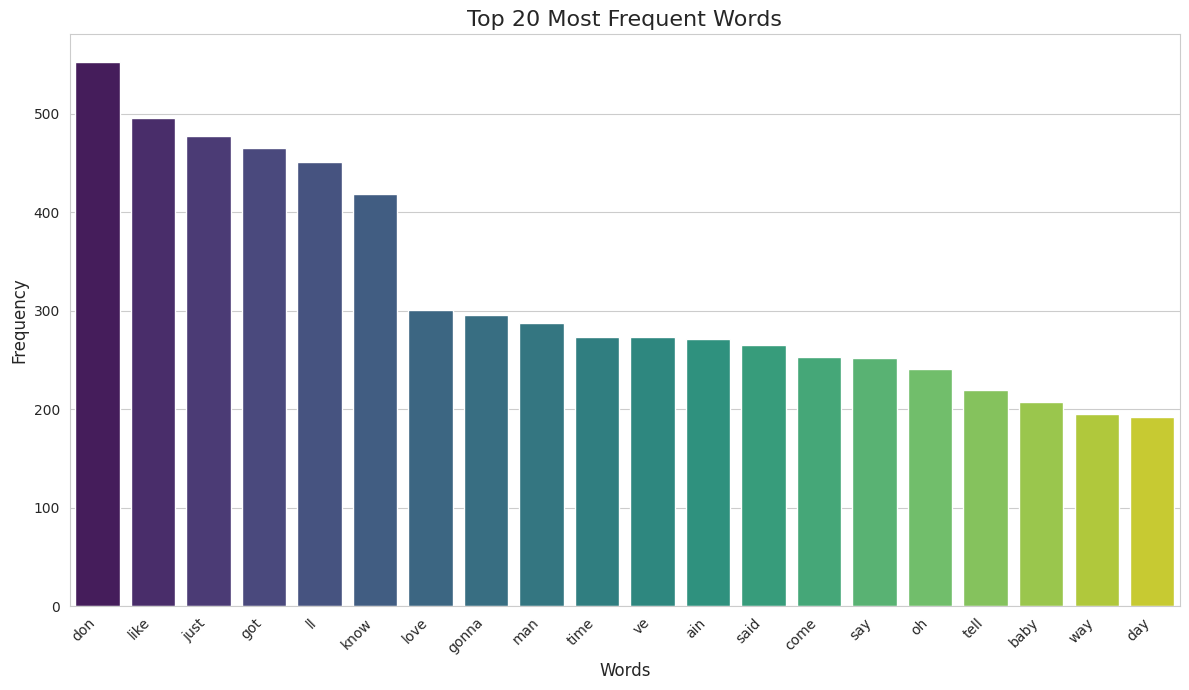

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract words and counts from the sorted_word_count list
words = [item[0] for item in sorted_word_count[:top_n_words]]
counts = [item[1] for item in sorted_word_count[:top_n_words]]

# Create a DataFrame for easier plotting with seaborn
most_frequent_words_df = pd.DataFrame({'Word': words, 'Count': counts})

# Create the bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='Word', y='Count', data=most_frequent_words_df, palette='viridis')
plt.title('Top 20 Most Frequent Words', fontsize=16)
plt.xlabel('Words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

### TF-IDF: Weighing Word Importance

TF-IDF stands for term frequency-inverse document frequency. It gives higher scores to words that appear often in a particular document but not too often across the entire collection. This helps reduce the influence of common words and highlight words that are more distinctive for a song.

In practice, TF-IDF is often more useful than raw word counts for comparing documents because it balances local importance with overall rarity.

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(stop_words='english')
X_tfidf = tfidf_vectorizer.fit_transform(corpus)

print(X_tfidf.shape)


(345, 7326)


### Clustering: Grouping Similar Songs

With the numeric representations, you can now perform clustering to group similar songs.

**K-means** is a popular algorithm that can partition a set of data points into K groups, where K is predefined.

In [19]:
from sklearn.cluster import KMeans

# Using TF-IDF vectors for clustering
kmeans = KMeans(n_clusters=5, random_state=0)  # Assuming we want to cluster into 5 groups
kmeans.fit(X_tfidf)

# Print cluster labels for each song
print(kmeans.labels_)

# Count the number of songs in each cluster (from KMeans)
cluster_counts = np.bincount(kmeans.labels_)

print("KMeans Cluster Sizes:")
for i, count in enumerate(cluster_counts):
    print(f"Cluster {i}: {count} songs")

[3 4 3 3 4 1 3 3 3 4 3 2 2 3 1 3 3 3 4 3 1 3 3 1 1 4 4 4 4 3 4 3 3 4 0 3 4
 1 1 0 1 3 3 3 3 1 0 3 1 4 3 3 1 3 2 1 3 3 3 3 3 3 4 0 1 3 4 1 1 1 3 1 4 3
 4 1 3 2 3 4 3 1 3 1 1 3 0 2 3 4 1 4 3 2 4 4 3 1 1 2 4 3 3 1 1 2 0 3 3 3 3
 4 4 0 4 4 3 3 3 2 0 3 0 4 4 0 1 1 2 3 3 0 3 3 3 3 1 3 0 3 1 1 3 2 3 3 1 2
 1 2 1 1 3 0 4 2 4 4 1 0 3 3 3 1 1 3 0 3 0 4 1 4 4 1 3 3 3 4 1 3 4 4 0 2 4
 3 4 2 4 0 1 3 3 1 4 1 3 1 3 1 3 1 1 0 4 3 1 1 3 1 4 1 3 2 1 0 2 3 1 1 1 0
 3 3 4 1 3 3 0 3 3 3 0 2 3 2 1 3 1 3 1 1 4 3 4 3 1 1 1 3 2 3 3 3 0 3 0 4 1
 3 3 3 1 4 1 1 1 3 4 4 3 3 4 3 3 3 1 3 3 4 3 0 4 3 3 3 3 3 2 3 3 2 3 3 3 3
 3 3 3 4 3 1 3 3 3 3 3 3 1 3 1 1 3 1 3 1 2 1 3 3 3 3 1 1 3 3 3 3 3 2 3 4 3
 1 1 1 4 2 3 3 3 3 3 2 3]
KMeans Cluster Sizes:
Cluster 0: 26 songs
Cluster 1: 82 songs
Cluster 2: 27 songs
Cluster 3: 154 songs
Cluster 4: 56 songs


**Hierarchical Clustering** is a different algorithm that agglomeratively groups similar objects into clusters, eventually forming a tree (hierarchy) of clusters.

Visualizing Clusters as a Tree (Dendrogram using Hierarchical Clustering):


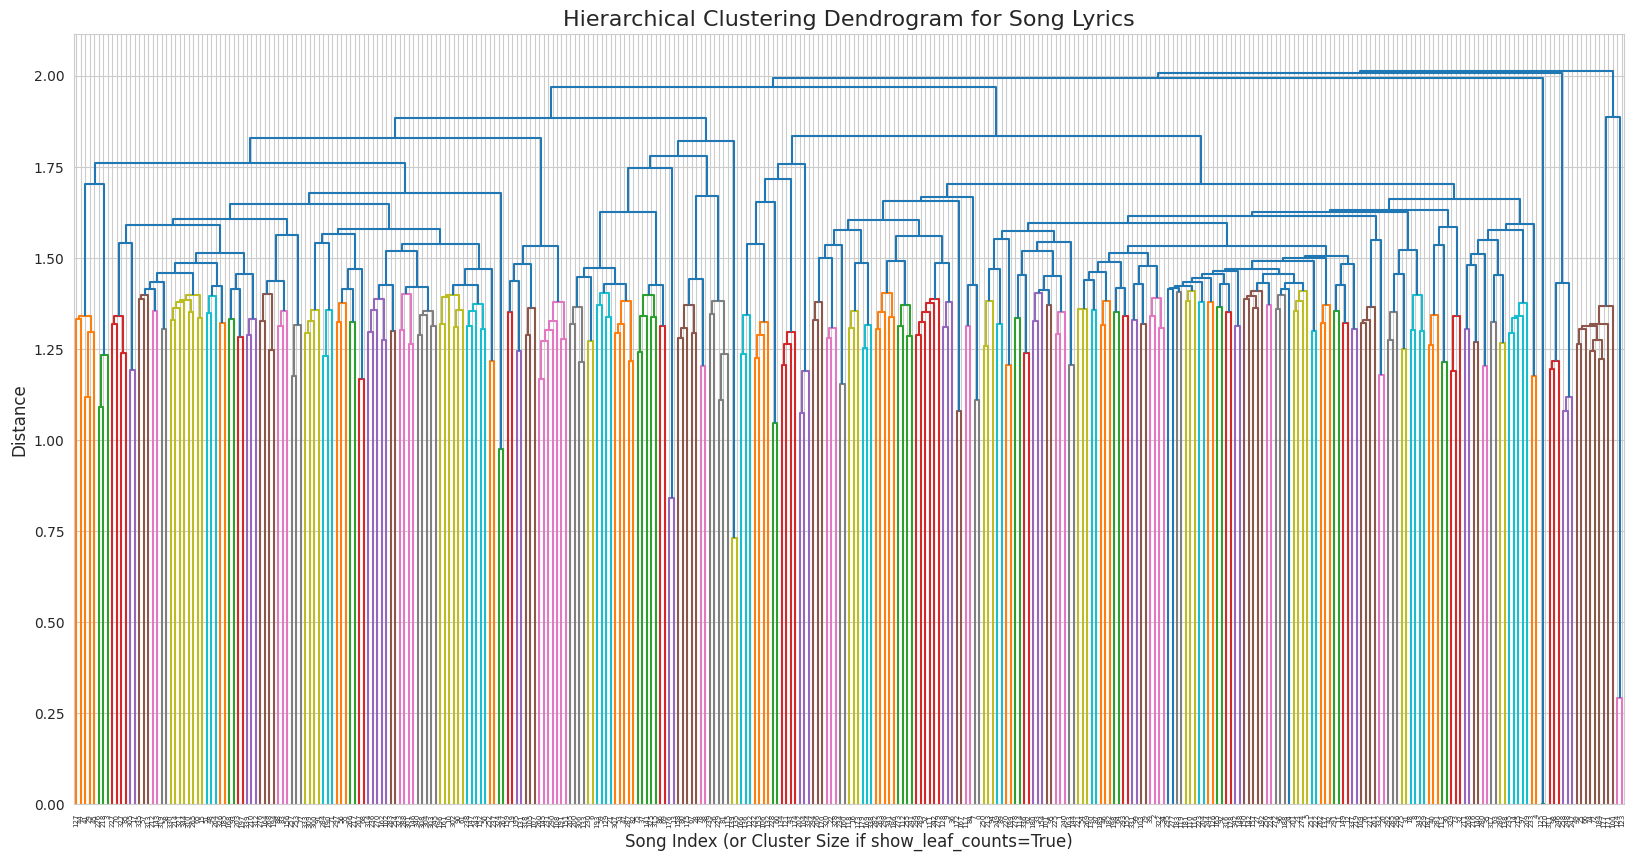

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

print("Visualizing Clusters as a Tree (Dendrogram using Hierarchical Clustering):")

# Perform hierarchical clustering on the TF-IDF vectors
# 'ward' linkage minimizes the variance of the clusters being merged.
# You can choose other methods like 'complete', 'average', 'single'.
linked = linkage(X_tfidf.toarray(), 'ward')

# Plot the dendrogram
plt.figure(figsize=(20, 10))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram for Song Lyrics', fontsize=16)
plt.xlabel('Song Index (or Cluster Size if show_leaf_counts=True)', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.show()

### Create a Word Cloud

A word cloud is a quick visual summary of common words. It is easy to read, but it should be treated as exploratory rather than analytical because it does not show exact counts or account for context.

In [21]:
# Install wordcloud package
#!pip install --upgrade wordcloud

In [22]:
# You may need to run this too.
#!pip install --upgrade Pillow

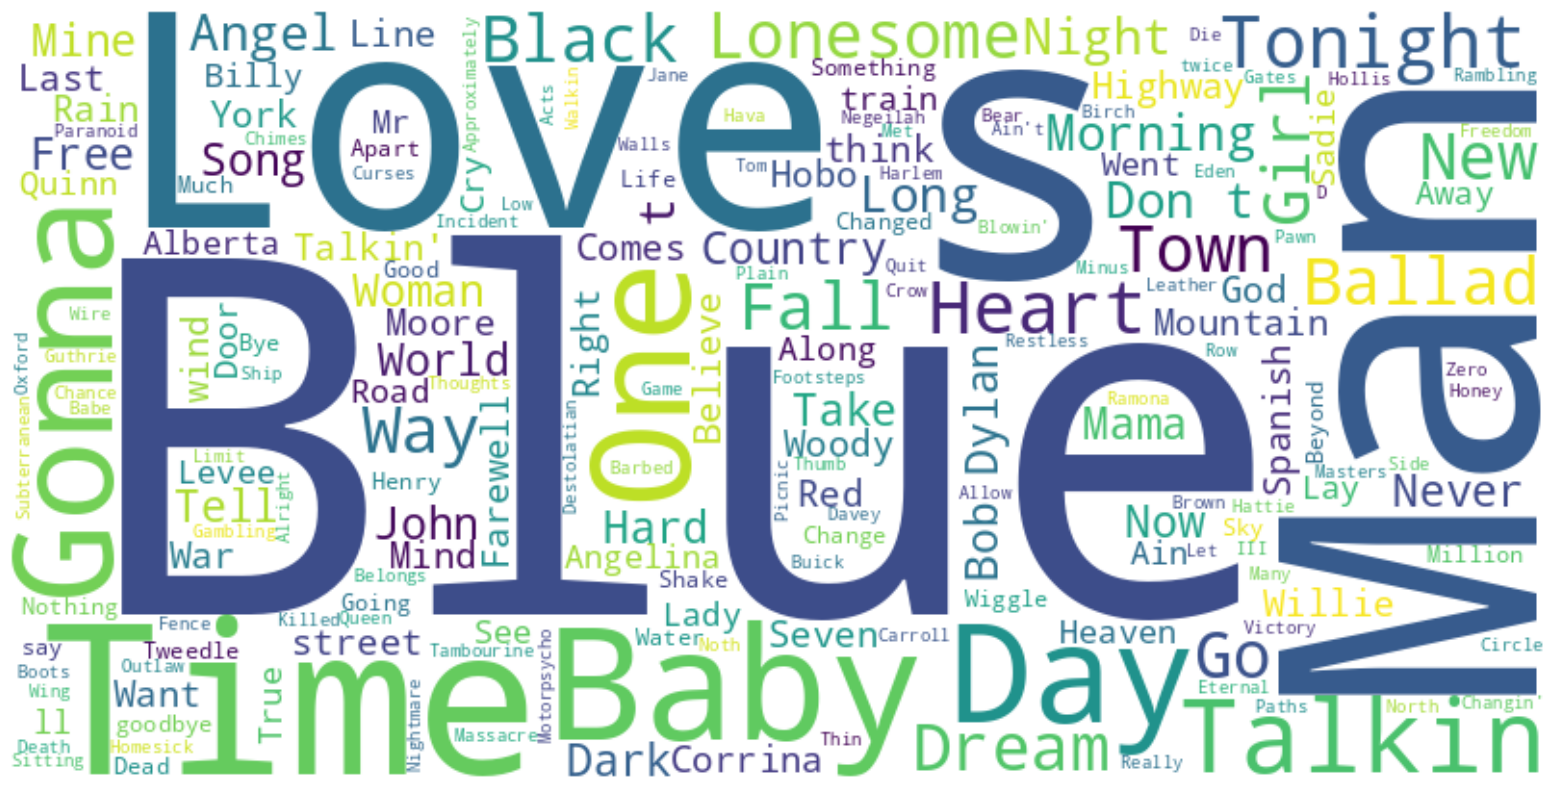

In [23]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all the text in the 'title' column into a single string
all_titles_text = " ".join(title for title in df['title'])

# Generate a word cloud image
wordcloud = WordCloud(background_color='white', width=800, height=400).generate(all_titles_text)

# Display the generated image
plt.figure(figsize=(20, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()


### Sentiment Analysis with a Pre-trained Model

For a simple sentiment analysis, you can use a pre-trained model from libraries such as TextBlob to estimate the sentiment score expressed in text.

TextBlob: https://textblob.readthedocs.io/en/dev/

In [24]:
# Install TextBlob
!pip install textblob

In [25]:
# This example uses TextBlob for sentiment analysis
from textblob import TextBlob

# Sample usage with the first five song's lyrics
for i in range(5):
    title = df['title'].iloc[i]
    lyrics = df['lyrics'].iloc[i]
    blob = TextBlob(lyrics)
    score = blob.sentiment.polarity
    print(f"{title}\t{lyrics[:25]}...\t{score}")

Hard Times In New York Town	Come you ladies and you g...	0.011896504729838058
Man on the street	’ll sing you a song, ain’...	-0.0692063492063492
Talkin’ Bear Mountain Picnic Massacre Blues	I saw it advertised one d...	0.14592111592111595
Let Me Die in My Footsteps	I will not go down under ...	-0.04433742183742184
Rambling, Gambling Willie	Come around you rovin’ ga...	-0.014664989664989669


## Exercises

Try these exercises to practice adapting the workflow above. Start by writing the code yourself, then compare your result with a partner or instructor.

In [26]:
# Exercise 1: Find the top 10 frequent words in Dylan's songs for each decade.
# Hint: loop through text_df.groupby('decade'), then fit a CountVectorizer to each decade's lyrics.
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

for decade, group in df.groupby('decade'):
    print(f"\n--- Decade: {decade}s ---")

    # Extract lyrics for the current decade, handling potential missing values
    decade_lyrics = group['lyrics'].dropna()

    if not decade_lyrics.empty:
        # Initialize and fit CountVectorizer
        vectorizer = CountVectorizer(stop_words='english')
        X = vectorizer.fit_transform(decade_lyrics)

        # Sum word counts across all songs in the decade
        word_counts = np.sum(X.toarray(), axis=0)

        # Get feature names (words)
        feature_words = vectorizer.get_feature_names_out()

        # Combine counts and words into a dictionary
        word_count_dict = {word: int(count) for word, count in zip(feature_words, word_counts)}

        # Sort the dictionary by counts in descending order
        sorted_word_count = sorted(word_count_dict.items(), key=lambda x: x[1], reverse=True)

        # Print the top 10 most frequent words for the decade
        top_n_words = 10
        print(f"Top {top_n_words} frequent words: {sorted_word_count[:top_n_words]}")
    else:
        print("No lyrics found for this decade.")


--- Decade: 1960s ---
Top 10 frequent words: [('just', 182), ('don', 152), ('like', 142), ('ll', 138), ('got', 135), ('ain', 127), ('know', 126), ('said', 103), ('come', 88), ('man', 84)]

--- Decade: 1970s ---
Top 10 frequent words: [('like', 146), ('don', 140), ('gonna', 125), ('just', 113), ('said', 98), ('know', 94), ('ll', 91), ('oh', 90), ('time', 89), ('got', 85)]

--- Decade: 1980s ---
Top 10 frequent words: [('don', 135), ('got', 110), ('know', 105), ('like', 97), ('just', 96), ('love', 87), ('man', 67), ('time', 64), ('ll', 60), ('baby', 59)]

--- Decade: 1990s ---
Top 10 frequent words: [('wiggle', 55), ('like', 42), ('don', 36), ('got', 31), ('god', 28), ('know', 27), ('til', 27), ('just', 26), ('knows', 22), ('gonna', 21)]

--- Decade: 2000s ---
Top 10 frequent words: [('got', 77), ('don', 57), ('ll', 52), ('gonna', 51), ('just', 44), ('know', 44), ('day', 41), ('say', 41), ('ain', 39), ('good', 39)]

--- Decade: 2010s ---
Top 10 frequent words: [('ll', 44), ('long', 32),

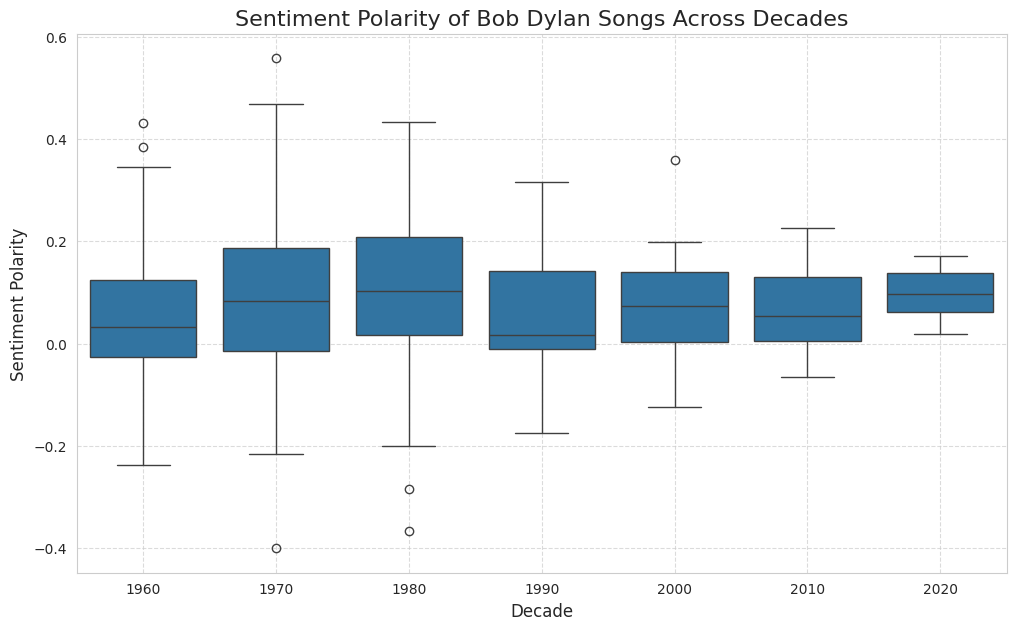

In [27]:
# Exercise 2: Create a boxplot showing sentiment scores across decades.
# Hint: use x='decade' and y='sentiment_polarity' with sns.boxplot().
import seaborn as sns
import matplotlib.pyplot as plt
from textblob import TextBlob

# Calculate sentiment polarity for each song's lyrics
# Drop rows where 'lyrics' might be missing before applying TextBlob
df['sentiment_polarity'] = df['lyrics'].dropna().apply(lambda x: TextBlob(x).sentiment.polarity)

# Create the boxplot
plt.figure(figsize=(12, 7))
sns.boxplot(x='decade', y='sentiment_polarity', data=df)
plt.title('Sentiment Polarity of Bob Dylan Songs Across Decades', fontsize=16)
plt.xlabel('Decade', fontsize=12)
plt.ylabel('Sentiment Polarity', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Working with Text Data from an API

Many API responses contain text data. For instance, the [NewsAPI](https://newsapi.org/) searches articles and breaking-news headlines from news sources and blogs across the web.

In this section, we will search recent news articles and convert the results into a DataFrame for text analysis.

To use the NewsAPI, you'll need an API key. It's recommended to store your API key securely in Colab's secrets manager under the "🔑" icon in the left panel. Name the secret `NEWS_API_KEY`.

In [28]:
from google.colab import userdata

NEWS_API_KEY = userdata.get('NEWS_API_KEY')
print(f"API Key: {NEWS_API_KEY}")

API Key: 25a8b04e60ce41c496d60442b9fcd492


In [29]:
import datetime

# Get today's date
today = datetime.date.today()

# Calculate the date three days ago
three_days_ago = today - datetime.timedelta(days=3)

# Format the date for the API request (YYYY-MM-DD)
from_param = three_days_ago.strftime('%Y-%m-%d')

print(f"Fetching news from: {from_param} to {today.strftime('%Y-%m-%d')}")

Fetching news from: 2026-05-28 to 2026-05-31


### Analyze the Text in the News Articles

What questions can we ask about this dataset?

- Which words appear most often in article titles or descriptions?
- Do different sources use different language for the same topic?
- How does sentiment vary across articles or sources?
- Are there clusters of articles that focus on different subtopics?

#1

In [30]:
import requests
import pandas as pd # Import pandas for DataFrame

query = input("Please enter your search query for news articles: ")
print(f"Searching for articles related to: {query}")

# NewsAPI endpoint for all articles
url = 'https://newsapi.org/v2/everything'

# Parameters for the request
params = {
    'pageSize': 100,    # Max number of articles to retrieve per request for 'everything' endpoint
    'apiKey': NEWS_API_KEY,
    'q': query, # The search query
    'from': from_param, # Start date for the search (already calculated)
    'to': today.strftime('%Y-%m-%d'), # End date for the search (today)
    'language': 'en' # Filter for English language articles
}

try:
    response = requests.get(url, params=params)
    response.raise_for_status() # Raise an exception for HTTP errors
    data = response.json()

    print("Successfully fetched news articles.")

    articles_data = []
    for article in data['articles']:
        source_name = article.get('source', {}).get('name', 'N/A')
        articles_data.append({
            'title': article.get('title'),
            'author': article.get('author'),
            'source': source_name,
            'description': article.get('description'),
            'date': article.get('publishedAt')
        })

    news_df = pd.DataFrame(articles_data)

    print(f"Total articles retrieved and saved to DataFrame: {len(news_df)}")
    print(f"Total results matching query (available from API): {data['totalResults']}")
    display(news_df.head())

except requests.exceptions.RequestException as e:
    print(f"Error fetching news: {e}")
    if response.status_code == 401:
        print("Unauthorized: Check your API key.")
    elif response.status_code == 429:
        print("Too Many Requests: You may have hit your API rate limit.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Please enter your search query for news articles: Apple
Searching for articles related to: Apple
Successfully fetched news articles.
Total articles retrieved and saved to DataFrame: 96
Total results matching query (available from API): 1191


,title,author,source,description,date
0,iPhone 18 Pro's Camera Upgrade Will Cost Apple...,Hartley Charlton,MacRumors,The iPhone 18 Pro and ‌iPhone 18 Pro‌ Max's al...,2026-05-29T10:44:01Z
1,When is an Apple Laptop Not a Macbook? When it...,Tyler August,Hackaday,"Do you remember, some years ago, when that bra...",2026-05-29T11:00:57Z
2,"Hold Off on Purchases, Students: Apple's Back ...",Juli Clover,MacRumors,Apple has started preparing for its annual Bac...,2026-05-28T17:38:59Z
3,Ferrari's polarizing new electric Luce is a be...,Tom Carter,Business Insider,"The Luce, a five-seat EV designed by ex-Apple ...",2026-05-28T09:49:10Z
4,Stephen Root on How He Got Into Character for ...,Cheryl Eddy,Gizmodo.com,Wyck is a salty curmudgeon who's witnessed hor...,2026-05-28T18:00:45Z


#Which words appear most often in article titles or descriptions?

In [31]:
from collections import Counter
import re

# Combine all titles and descriptions into one string
text = " ".join(
    news_df["title"].fillna("").astype(str) + " " +
    news_df["description"].fillna("").astype(str)
)

# Convert to lowercase and extract words
words = re.findall(r'\b[a-z]+\b', text.lower())

# Remove common stop words
stop_words = {
    'the','a','an','and','or','but','of','to','in','on','for','with',
    'at','by','from','is','are','was','were','be','been','has','have',
    'had','will','would','could','should','that','this','it','its',
    'as','about','after','before','over','under','into','than'
}

filtered_words = [word for word in words if word not in stop_words]

# Count word frequencies
word_counts = Counter(filtered_words)

# Show top 20 words
top_words = pd.DataFrame(
    word_counts.most_common(20),
    columns=["Word", "Frequency"]
)

display(top_words)

,Word,Frequency
0,apple,113
1,s,109
2,new,53
3,more,45
4,iphone,21
5,here,21
6,macbook,19
7,ios,19
8,first,19
9,tv,18


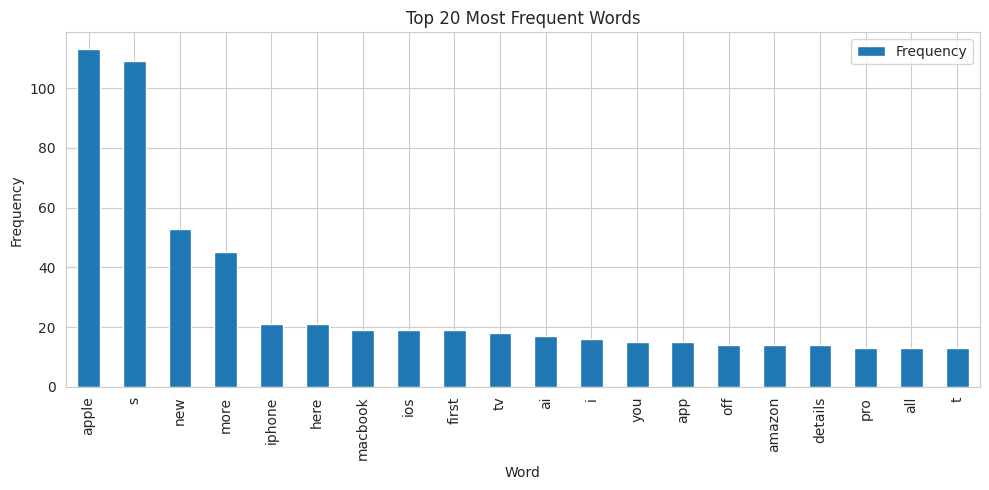

In [32]:
import matplotlib.pyplot as plt

top_words.plot(
    x="Word",
    y="Frequency",
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 20 Most Frequent Words")
plt.ylabel("Frequency")
plt.xlabel("Word")
plt.tight_layout()
plt.show()

#2

In [33]:
from collections import Counter
import pandas as pd
import re

stop_words = {
    'the','a','an','and','or','but','of','to','in','on','for','with',
    'at','by','from','is','are','was','were','be','been','has','have',
    'had','will','would','could','should','that','this','it','its',
    'as','about','after','before','over','under','into','than'
}

for source in news_df['source'].dropna().unique():

    text = " ".join(
        news_df[news_df['source'] == source]['title'].fillna('') +
        " " +
        news_df[news_df['source'] == source]['description'].fillna('')
    )

    words = re.findall(r'\b[a-z]+\b', text.lower())
    words = [w for w in words if w not in stop_words]

    counts = Counter(words)

    print(f"\nTop words for {source}")
    print(counts.most_common(10))


Top words for MacRumors
[('s', 16), ('apple', 15), ('ai', 8), ('macbook', 5), ('new', 4), ('back', 4), ('search', 4), ('iphone', 3), ('pro', 3), ('more', 3)]

Top words for Hackaday
[('when', 3), ('apple', 2), ('laptop', 2), ('not', 2), ('macbook', 1), ('s', 1), ('ii', 1), ('do', 1), ('you', 1), ('remember', 1)]

Top words for Business Insider
[('i', 4), ('trump', 3), ('accounts', 3), ('app', 3), ('ferrari', 2), ('s', 2), ('luce', 2), ('downloaded', 2), ('my', 2), ('polarizing', 1)]

Top words for Gizmodo.com
[('s', 7), ('new', 4), ('t', 4), ('all', 3), ('season', 3), ('neo', 2), ('if', 2), ('aren', 2), ('now', 2), ('first', 2)]

Top words for The Verge
[('s', 6), ('motorola', 3), ('razr', 3), ('ultra', 3), ('i', 3), ('you', 3), ('rivian', 3), ('half', 2), ('off', 2), ('just', 2)]

Top words for Android Central
[('s', 4), ('home', 3), ('market', 2), ('one', 2), ('android', 2), ('maker', 2), ('out', 2), ('samsung', 2), ('new', 2), ('digital', 2)]

Top words for CNET
[('s', 8), ('apple'

#Do different sources use different language for the same topic?

In [34]:
results = []

for source in news_df['source'].dropna().unique():

    text = " ".join(
        news_df[news_df['source'] == source]['title'].fillna('') +
        " " +
        news_df[news_df['source'] == source]['description'].fillna('')
    )

    words = re.findall(r'\b[a-z]+\b', text.lower())
    words = [w for w in words if w not in stop_words]

    counts = Counter(words)

    for word, freq in counts.most_common(10):
        results.append([source, word, freq])

comparison_df = pd.DataFrame(
    results,
    columns=['Source', 'Word', 'Frequency']
)

display(comparison_df)

,Source,Word,Frequency
0,MacRumors,s,16
1,MacRumors,apple,15
2,MacRumors,ai,8
3,MacRumors,macbook,5
4,MacRumors,new,4
...,...,...,...
272,Deadline,pic,2
273,Deadline,liminal,2
274,Deadline,join,1
275,Deadline,exclusive,1


#3

In [35]:
from textblob import TextBlob

# Combine title and description
news_df['text'] = (
    news_df['title'].fillna('') + ' ' +
    news_df['description'].fillna('')
)

# Calculate sentiment polarity (-1 to 1)
news_df['sentiment'] = news_df['text'].apply(
    lambda x: TextBlob(x).sentiment.polarity
)

news_df[['source', 'title', 'sentiment']].head()

,source,title,sentiment
0,MacRumors,iPhone 18 Pro's Camera Upgrade Will Cost Apple...,0.333333
1,Hackaday,When is an Apple Laptop Not a Macbook? When it...,0.275000
2,MacRumors,"Hold Off on Purchases, Students: Apple's Back ...",0.100000
3,Business Insider,Ferrari's polarizing new electric Luce is a be...,0.134091
4,Gizmodo.com,Stephen Root on How He Got Into Character for ...,0.000000


In [36]:
source_sentiment = (
    news_df.groupby('source')['sentiment']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

display(source_sentiment)

,source,sentiment
0,Techdirt,0.500000
1,Css-tricks.com,0.379545
2,Apple Newsroom,0.375000
3,Slickdeals.net,0.308333
4,Hackaday,0.275000
5,Mental Floss,0.250000
6,Deadline,0.237500
7,MacRumors,0.232381
8,Kotaku,0.216667
9,/FILM,0.200000


#How does sentiment vary across articles or sources?

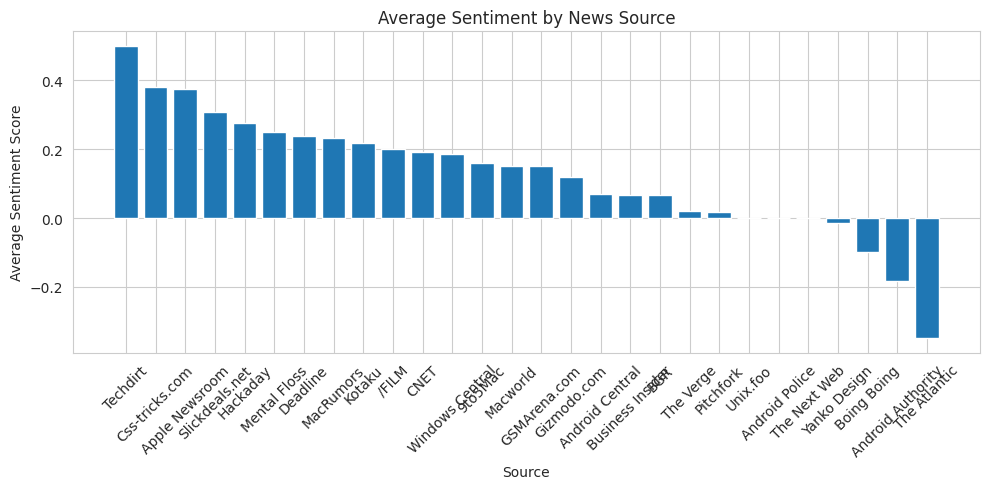

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(
    source_sentiment['source'],
    source_sentiment['sentiment']
)

plt.title('Average Sentiment by News Source')
plt.xlabel('Source')
plt.ylabel('Average Sentiment Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#4

In [38]:
news_df['text'] = (
    news_df['title'].fillna('') + ' ' +
    news_df['description'].fillna('')
)

In [39]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=1000
)

X = vectorizer.fit_transform(news_df['text'])

In [40]:
from sklearn.cluster import KMeans

k = 5  # number of clusters

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

news_df['cluster'] = kmeans.fit_predict(X)


#Are there clusters of articles that focus on different subtopics?



In [41]:
terms = vectorizer.get_feature_names_out()

for i in range(k):
    center = kmeans.cluster_centers_[i]
    top_indices = center.argsort()[-10:][::-1]

    print(f"\nCluster {i}")
    print([terms[idx] for idx in top_indices])


Cluster 0
['home', 'apple', 'gaming', 'tv', 'works', 'smart', 'speech', 'dead', 'finally', 'let']

Cluster 1
['apple', 'tv', 'watch', 'glucose', 'android', 'series', 'music', 'details', 'linux', 'mankind']

Cluster 2
['new', 'ai', '27', 'ios', 'iphone', 'apple', 'siri', 'app', 'wwdc', 'report']

Cluster 3
['macbook', 'amazon', 'air', 'apple', 'laptop', 'm5', 'neo', 'wireless', 'price', '99']

Cluster 4
['26', 'beta', 'public', 'macos', 'expect', 'ipados', 'apple', 'betas', 'update', 'ios']
